bonjour


In [1]:
x=18

In [2]:
x

18

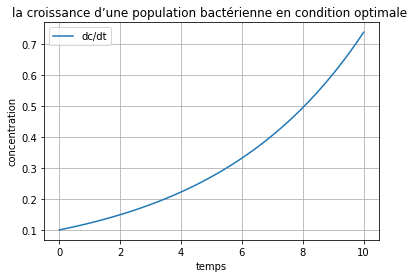

In [17]:
import numpy as np
import matplotlib.pyplot as plt
# Paramètres de la simulation
rmax = 0.2 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)
# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)
# Tracé du graphique
plt.title('la croissance d’une population bactérienne en condition optimale ') # Titre du graphique
plt.plot(time, C, label='dc/dt') # Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

Figure 1 

1-c'est une courbe exsponetielle 

2-La population double en : 
on a r max = 0.2 pour 3.5 h 
r max = 0.1 pour 7h
r max = 0 pour aucun dédoublement ( ligne droite ) içi la population est constatnte 
r max = -0.1 içi la courbe décroit 

3 -analyse des résultat : 
on remarque que plus on augmente la valeur de r max plus la vitesse diminue en fonction du temps ( 0.2 à 0.1 ) jusqu'a attendre une valeur constante ou r max = 0 et la courbe décroit quand r max = 0 

4 - les limites de ce codes , c'est qu'il compte la disponibilite , par conséquant il va falloir integrer la disponibilité pour le rendre plus réaliste 

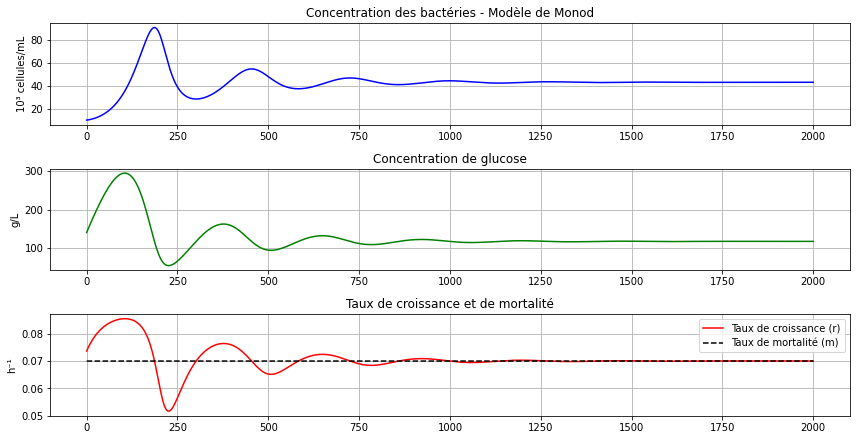

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]
     # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

1 - déscription des différentes courbes : 

la courbe 1(bleu) des concentration des bactéries - Modéle de Monod , on remarque que la augmente assez rapidement jusqu'a attendre un maximum de croissance puis la courbe diminue jusuq'a a ne plus avoir de nouvelles cellules formées . 

la courbe 2 (vert) içi le paramétre de la concentration du glucose est rajoutée , on remarque que le glucose agit comme un carburant la croissance des bactéries , dés que sa concentration commentce à diminue dans le milieu la population chute ce qui témoigne que le glucose a été epuisée . 

la courbe 3 ( rouge / pointillé ) ici on constate que le taux de mortalité est constant ( ligne droite en pointillé  ) , comparé au taux de croissance ( rouge )  qui au départ étais maximale puis il diminue suivant un cheminement logique au fil du temps .

les bacréries s'ecroulent suit à leur comsommation de glucose 

en conslusion le facteur limitant est le substrat enérgitique qui est le glucose  .


2 - la population atteindsson maximun quand r = 1 selon le graphe de taux de croissance 

3 - Modifications de paramétre 
augmenter le r pour une croissance plus rapide du glucose 
augmenter m pour une mortalité plus importante 
augmenter le k pour une affinité plus faible pour le glucose et une croissance moins efficase 

4- pour que la population se maintienne dans le temps : 
il faut passer d'un systéme ferme à un systeme ouvert il est important d'apporter un flux de nutriments pour compenser la consomation 

5- description des courbes 
la population bactérienne montre d'importantes oscilliations amorties avant de se stabiliser sur une ligne droite parfaite c'est un etat d'equilibre entre le ttaux de croissance et le taux de mortalite , on a egalement le glucose qui se stabilise . 
la population présente des fluctuations marquée avant de se déstabiliser :initialement l'excée de glucose provoque une proliferation , devenues trop nombreuses les bacteries surcomsomment le glucose qui s'epuise et entraine une chute , le glucose augmente a nouveau dans le milieu ce qui permet au bacterie de nouveau re croitre cette fois en trouvant un equilibre entre le taux de croissance / taux de mortalité

In [20]:
import numpy as npimport matplotlib.pyplot as plt# =============================================# Paramètres pour la souche 1# =============================================rmax_1 = 0.15 # Taux de croissance maximal (souche 1)m0_1 = 0.06 # Taux de mortalité de base (souche 1)K_1 = 800 # Constante de demi-saturation (souche 1)# =============================================# Paramètres pour la souche 2# =============================================rmax_2 = 0.15 # Taux de croissance maximal (souche 2)m0_2 = 0.06 # Taux de mortalité de base (souche 2)K_2 = 650 # Constante de demi-saturation (souche 2) -affinité plus élevée pour le glucose# =============================================# Paramètres du glucose# =============================================initial_glucose = 1200 # Quantité initiale de glucoseglucose_inflow = 4 # Flux entrant de glucose (0 = système fermé)# =============================================# Conditions initiales# =============================================C0_1 = 10 # Concentration initiale de la souche 1C0_2 = 10 # Concentration initiale de la souche 2# =============================================# Paramètres de la simulation# =============================================dt = 0.1 # Pas de tempsT = 2000 # Durée totale de la simulationN_steps = int(T / dt)# Nombre de pas de temps


SyntaxError: invalid syntax (<ipython-input-20-d6295857db97>, line 1)

In [21]:
import numpy as npimport matplotlib.pyplot as plt# =============================================# Paramètres pour la souche 1# =============================================rmax_1 = 0.15 # Taux de croissance maximal (souche 1)m0_1 = 0.06 # Taux de mortalité de base (souche 1)K_1 = 800 # Constante de demi-saturation (souche 1)# =============================================# Paramètres pour la souche 2# =============================================rmax_2 = 0.15 # Taux de croissance maximal (souche 2)m0_2 = 0.06 # Taux de mortalité de base (souche 2)K_2 = 650 # Constante de demi-saturation (souche 2) -affinité plus élevée pour le glucose# =============================================# Paramètres du glucose# =============================================initial_glucose = 1200 # Quantité initiale de glucoseglucose_inflow = 4 # Flux entrant de glucose (0 = système fermé)# =============================================# Conditions initiales# =============================================C0_1 = 10 # Concentration initiale de la souche 1C0_2 = 10 # Concentration initiale de la souche 2# =============================================# Paramètres de la simulation# =============================================dt = 0.1 # Pas de tempsT = 2000 # Durée totale de la simulationN_steps = int(T / dt)# Nombre de pas de temps

SyntaxError: invalid syntax (<ipython-input-21-d6295857db97>, line 1)

In [22]:
mport numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps
# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)
# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (<ipython-input-22-d2d9d83995cb>, line 1)

In [23]:
mport numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (<ipython-input-23-5b83b6bc2844>, line 1)

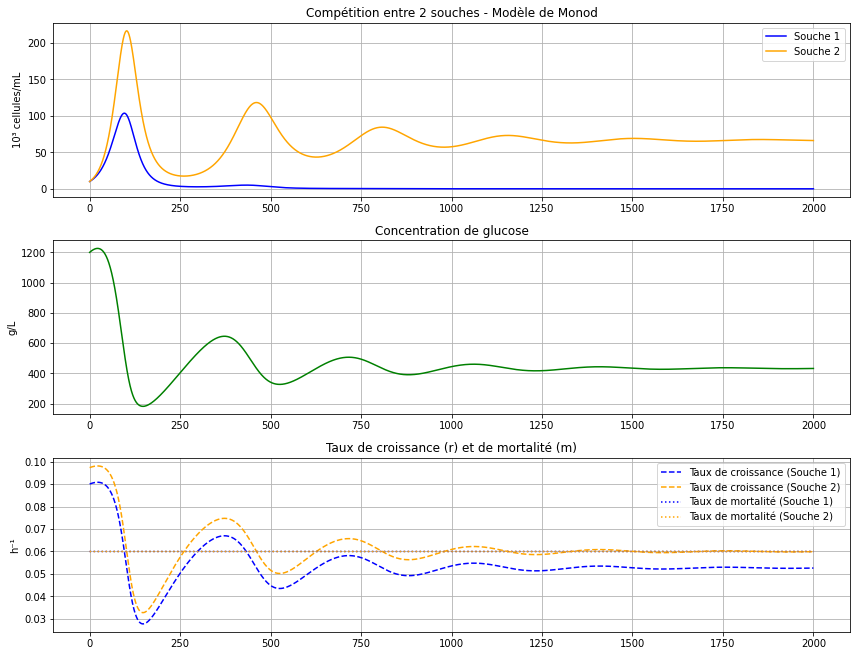

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

1- description des courbe les deux souches croissent au depart puis la souche 2 devvient progressivement dominant en detriment de la souche 1 qui finit par disparaitre 

2- le resultat de la concurence sur le devenir des populations est que la souche dominante (2) possede un k plus faible donc qui a une meilleur affinité pour le glucose donc elle peut croitre quand le glucose est faiblre 
on conclue que la souche la plus adaptée élimine progressivement l'autre 

3 - effect du parametre m de la souche 1 
si on diminuent la mortalité de la souche 1 elle devient plus competitive et finit par l'emporter sur la souche 2 dés que sont taux de mortalité est suffisament faible pour que son taux de croissance net 

4 - les conditions d'un équilibre entre les deuc souche serait : il faudrait que leur taux de croissance net soit rigoureusement identiques pour la concentration de substrat à l'équilibre 


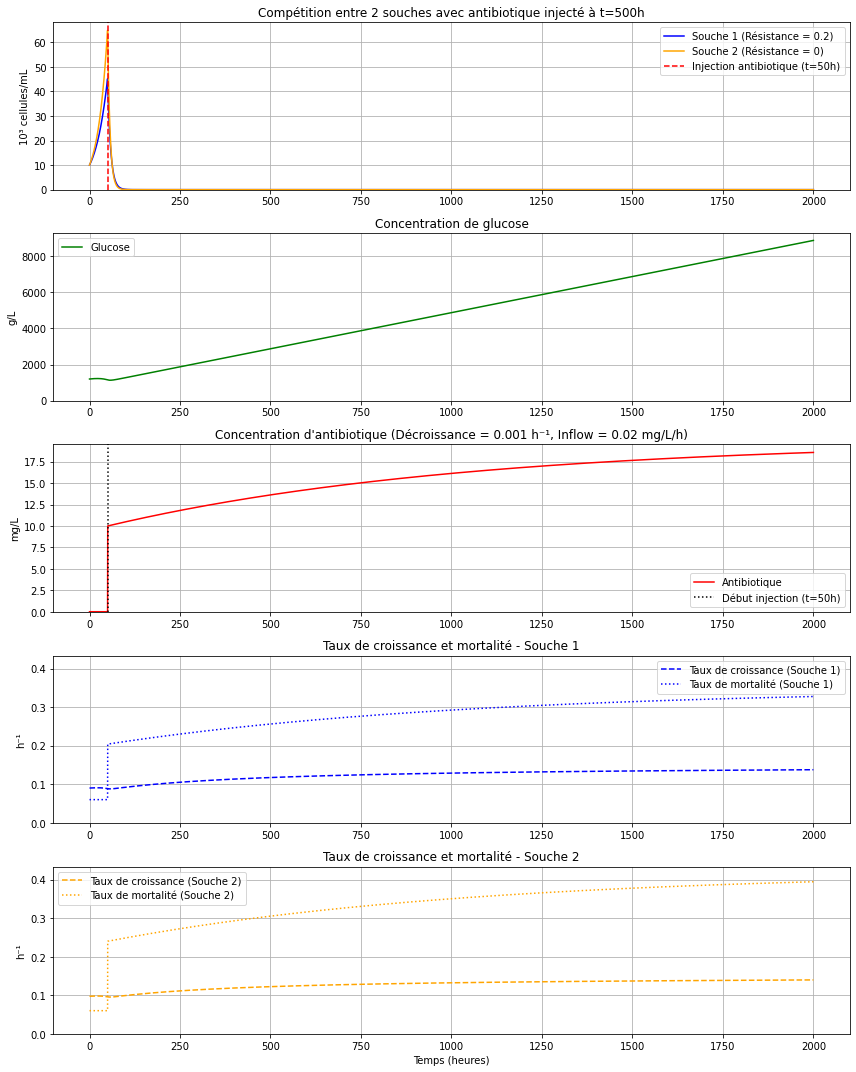

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.06        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0.2  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.06        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 4      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.001    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0.02      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 2000          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

1- cas d'ajout antibiotique = 10 
le taux de mortalité augmente et la population bactérienne diminue 
qyand ATB disparait certaines bactéries peuvent se re proliferer 


2- cas de la résistance : la souche 1 devient insensivle à l'antibiotique ce qui est l'oposée de la souche 2 



3 - resistance = 0.2 de la souche 1 : elle est partiellement resistance elle survit mieux que la souche 2 sa frequence augmenet mais son avantage est moins fort 


4 - pollution diffuse de L'ATP : 
le flux entrant constant empeche l'antibiotique de disparaitre du milieur maintanat une pression de selection continue meme si la souche 1 n'est pas faiblement resistante la hausse de la mortalite subit par la souche 2 annule son avantage lié à l'affinité pour le glucose 
c'est ce que appele une demonstation du danger des concentrations sub inhibitrices d'antibiotique dans un environemment 
